In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error
import optuna
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import lime
import scipy.stats as stats
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

In [2]:
%ls -lah ~/ai-course-env/main-work-folder/kaggle/1

total 1.2M
drwxrwxr-x 5 alice3e alice3e 4.0K Apr 16 11:38 ./
drwxrwxr-x 4 alice3e alice3e 4.0K Apr 15 17:37 ../
-rw-rw-r-- 1 alice3e alice3e 640K Apr 16 11:37 1_competition.ipynb
-rw-rw-r-- 1 alice3e alice3e 542K Apr 16 08:44 2.ipynb
-rw-rw-r-- 1 alice3e alice3e    0 Apr 15 17:37 andrei.ipynb
drwxrwxr-x 5 alice3e alice3e 4.0K Apr 15 19:10 catboost_info/
drwxrwxr-x 2 alice3e alice3e 4.0K Apr 15 17:37 data/
drwxrwxr-x 2 alice3e alice3e 4.0K Apr 16 11:34 .ipynb_checkpoints/


In [4]:
#train = pd.read_csv('~/ai-course-env/main-work-folder/kaggle/1/data/period_1_train_data.csv')
#test = pd.read_csv('~/ai-course-env/main-work-folder/kaggle/1/data/test_x.csv')
train = pd.read_csv('data/period_1_train_data.csv')
test = pd.read_csv('data/test_x.csv')
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (29905, 83), Test shape: (7477, 83)


# Исследование данных
#### Анализ target

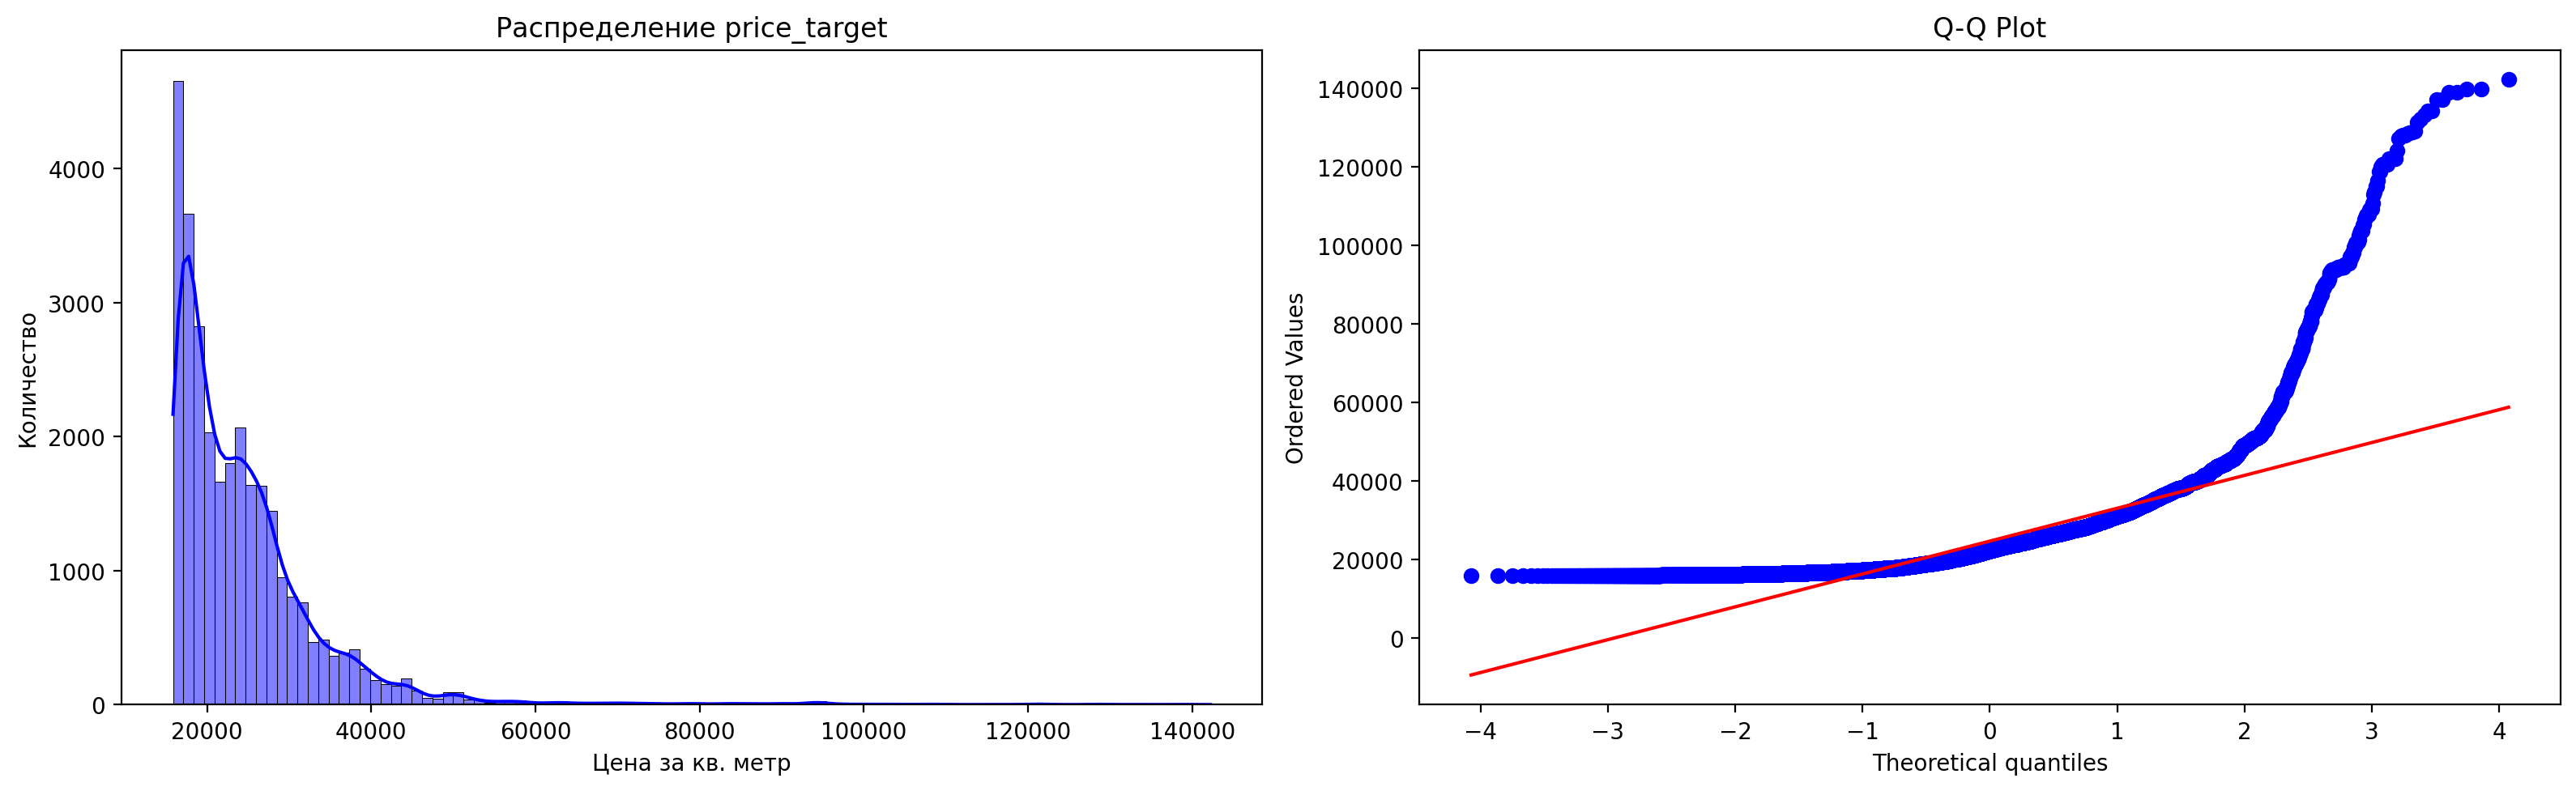

Минимум: 15859.27
Максимум: 142207.32
Медиана: 22257.19
Среднее: 24606.73
Skewness (Асимметрия): 3.82
Kurtosis (Эксцесс): 25.46



In [5]:
target = 'price_target'
def analyze_target(df, target_col):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(df[target_col], kde=True, bins=100, ax=axes[0], color='blue')
    axes[0].set_title(f'Распределение {target_col}')
    axes[0].set_xlabel('Цена за кв. метр')
    axes[0].set_ylabel('Количество')
    
    stats.probplot(df[target_col], dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()
    print(f"Минимум: {df[target_col].min():.2f}")
    print(f"Максимум: {df[target_col].max():.2f}")
    print(f"Медиана: {df[target_col].median():.2f}")
    print(f"Среднее: {df[target_col].mean():.2f}")
    print(f"Skewness (Асимметрия): {df[target_col].skew():.2f}")
    print(f"Kurtosis (Эксцесс): {df[target_col].kurt():.2f}\n")
analyze_target(train, target)

In [6]:
def detect_outliers(df, target_col):
    print("=== 2. ПОИСК ВЫБРОСОВ В ТАРГЕТЕ ===")
    
    # Межквартильный размах (IQR) 
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    outliers_iqr = df[(df[target_col] < lower_iqr) | (df[target_col] > upper_iqr)]

    print(f"(IQR): Найдено {len(outliers_iqr)} выбросов "
          f"(границы: {lower_iqr:.1f} - {upper_iqr:.1f})")
detect_outliers(train, target)

=== 2. ПОИСК ВЫБРОСОВ В ТАРГЕТЕ ===
(IQR): Найдено 1259 выбросов (границы: 3588.1 - 42070.5)


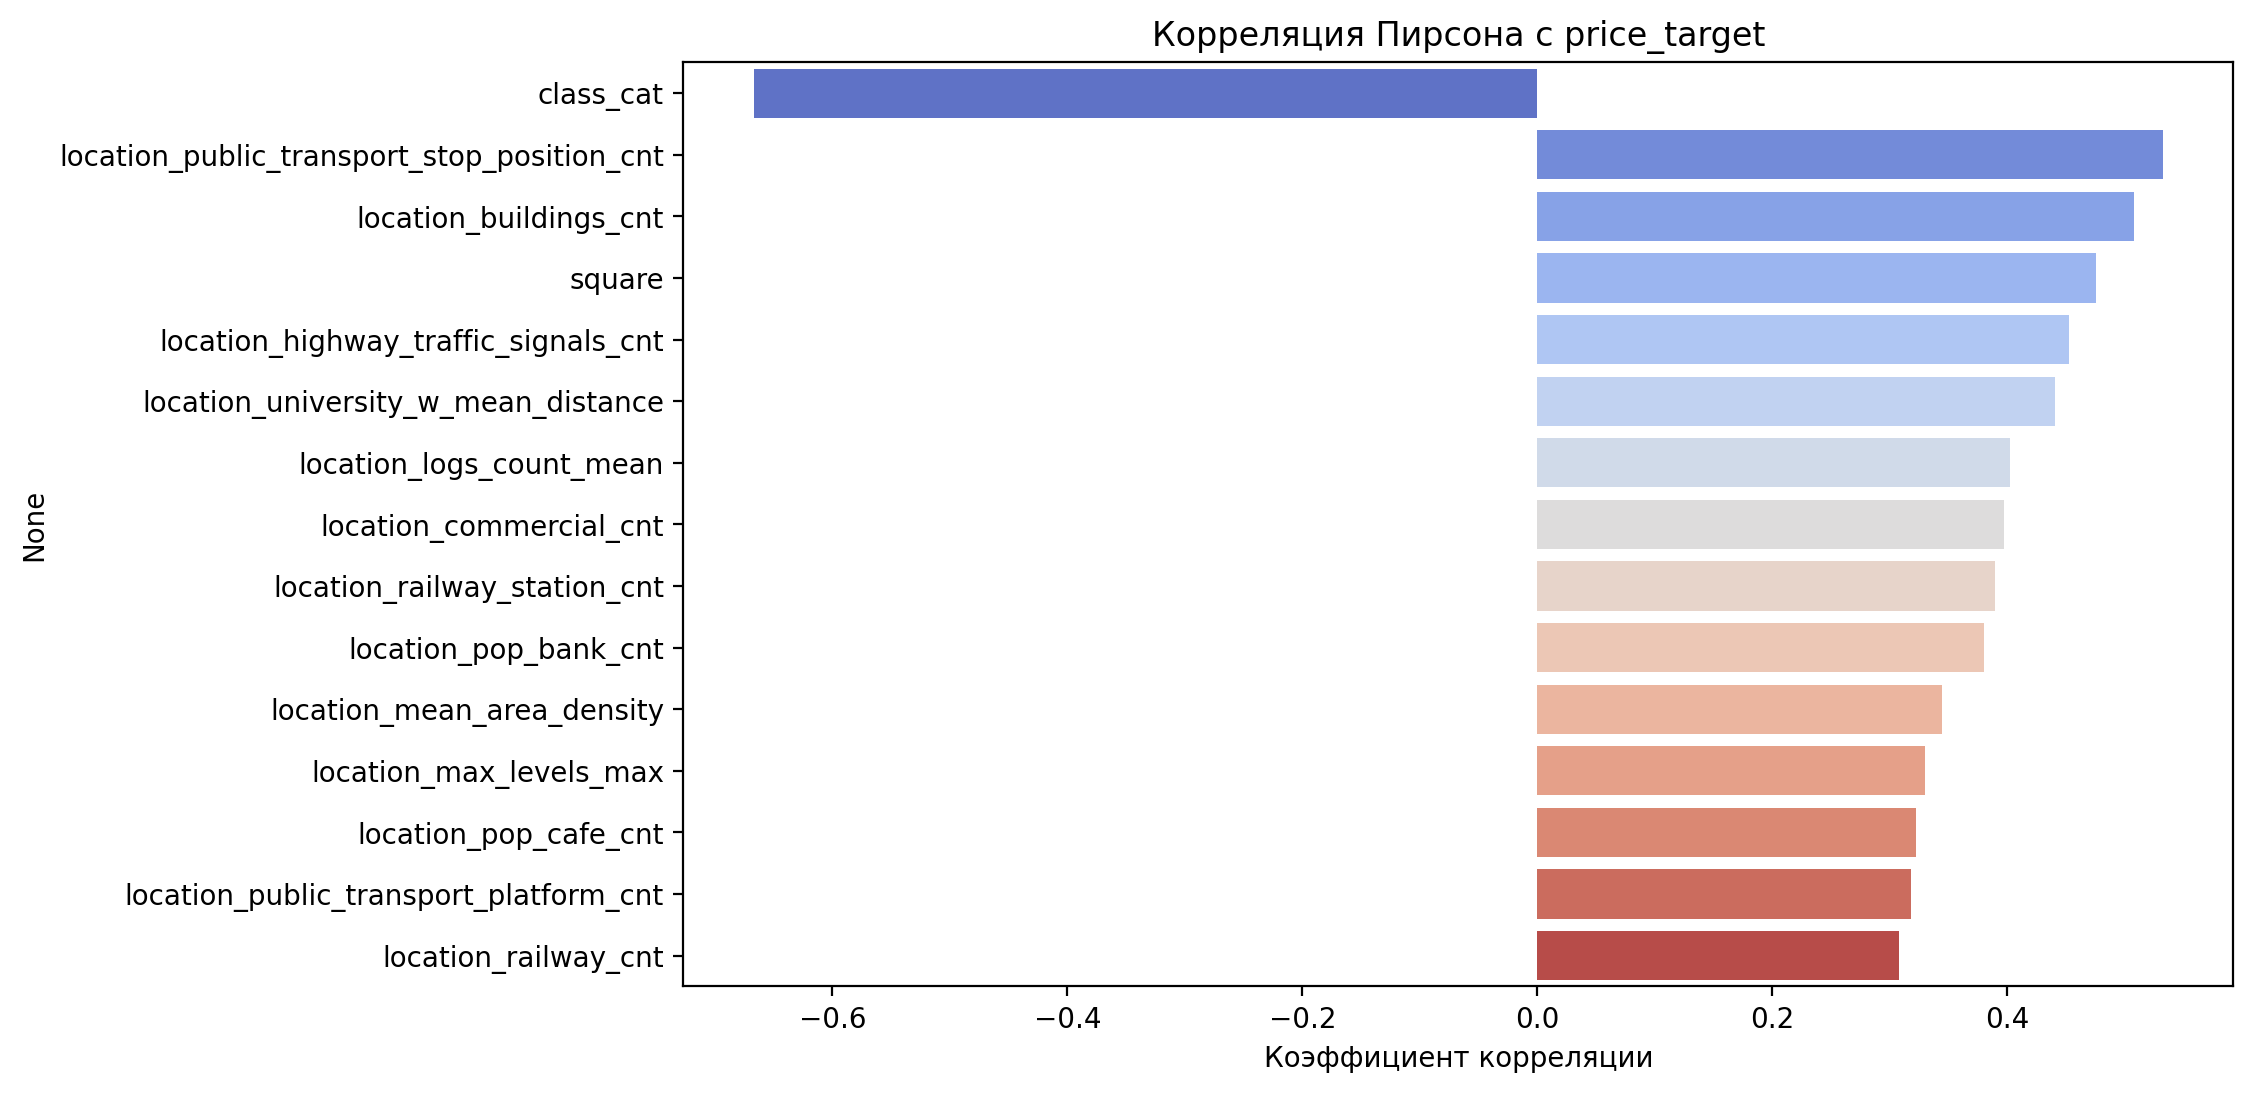

In [7]:
def get_top_correlations(df, target_col, top_n=15):
    num_cols = df.select_dtypes(include=[np.number]).columns  
    corr_pearson = df[num_cols].corr(method='pearson')[target_col].drop(target_col)
    
    top_features = corr_pearson.abs().sort_values(ascending=False).head(top_n).index
    # Визуализация
    plt.figure(figsize=(10, 6))
    sns.barplot(x=corr_pearson[top_features].values, y=top_features, palette='coolwarm')
    plt.title('Корреляция Пирсона с price_target')
    plt.xlabel('Коэффициент корреляции')
    plt.show()

get_top_correlations(train, target, top_n=15)

In [8]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def analyze_missing_values(df):
    print("=== 1. СВОДКА ПО ПРОПУСКАМ ===")
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_df = pd.DataFrame({
        'count': missing_count,
        'percent': missing_percent,
        'dtype': df.dtypes
    })
    missing_df = missing_df[missing_df['count'] > 0].sort_values(by='percent', ascending=False)
    
    print(f"Всего колонок с пропусками: {len(missing_df)}\n")
    print(missing_df.round(2))
    return missing_df
missing_info = analyze_missing_values(train)


=== 1. СВОДКА ПО ПРОПУСКАМ ===
Всего колонок с пропусками: 70

                                                    count  percent    dtype
location_logs_count_mean                              333     1.11  float64
location_tourism_w_mean_distance                      333     1.11  float64
location_village_cnt                                  333     1.11  float64
location_shop_product_w_mean_distance                 333     1.11  float64
location_residential_cnt                              333     1.11  float64
location_market_cnt                                   333     1.11  float64
location_motel_cnt                                    333     1.11  float64
location_shop_alco_cnt                                333     1.11  float64
location_amenity_leisure_w_mean_distance              333     1.11  float64
location_highway_crossing_w_mean_distance             333     1.11  float64
location_marketplace_w_mean_distance                  333     1.11  float64
location_school_w_mean_di

=== РЕЗУЛЬТАТЫ ПОСЛЕ ЛОГАРИФМИРОВАНИЯ ===


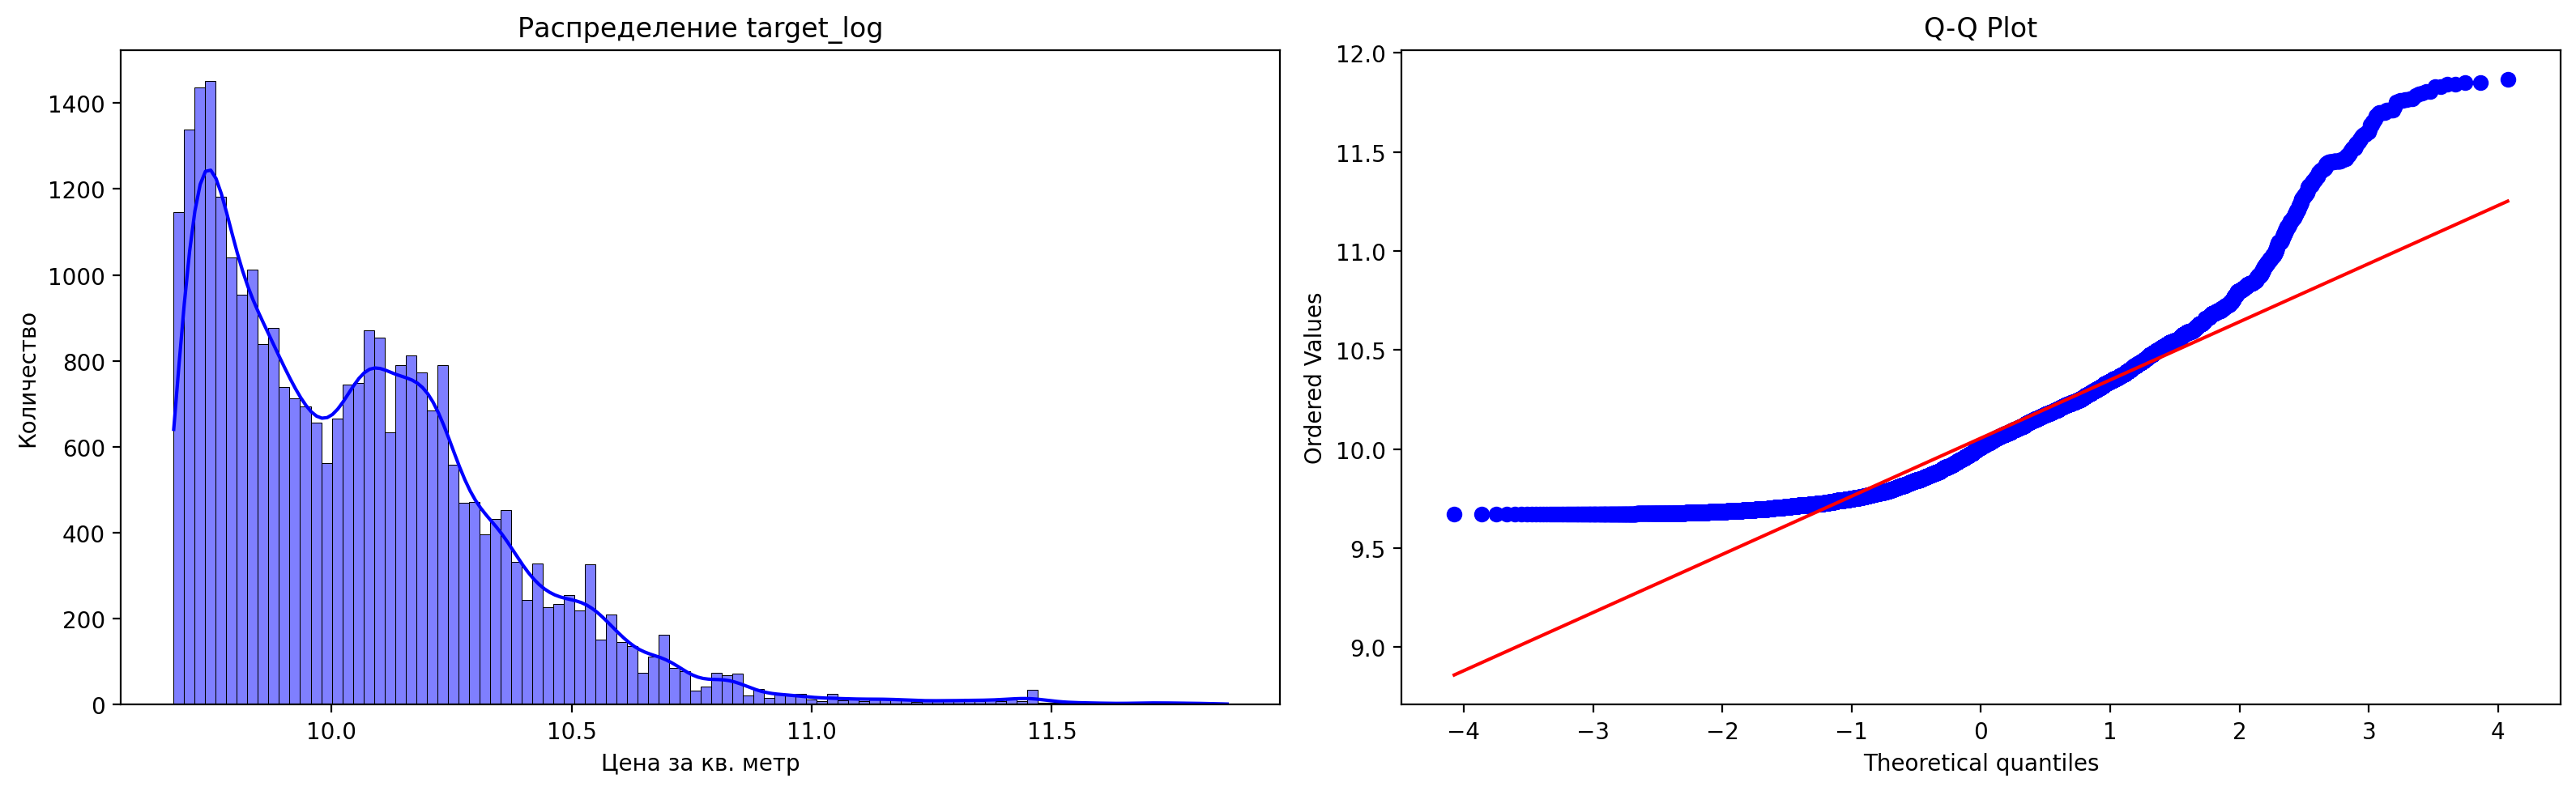

Минимум: 9.67
Максимум: 11.87
Медиана: 10.01
Среднее: 10.06
Skewness (Асимметрия): 1.28
Kurtosis (Эксцесс): 2.71

=== 2. ПОИСК ВЫБРОСОВ В ТАРГЕТЕ ===
(IQR): Найдено 485 выбросов (границы: 9.2 - 10.9)
=== СВЯЗЬ ПРОПУСКОВ И ЦЕНЫ ===
            Статус  Медианная цена (target)
0  Гео-данные есть             22299.662862
1   Гео-данных нет             20973.161346


In [9]:
train_prep = train.copy()
train_prep['target_log'] = np.log1p(train_prep[target])

print("=== РЕЗУЛЬТАТЫ ПОСЛЕ ЛОГАРИФМИРОВАНИЯ ===")
analyze_target(train_prep, 'target_log')
detect_outliers(train_prep, 'target_log')

# 2. Создаем бинарный флаг пропусков по гео-признакам
train_prep['is_location_missing'] = train_prep['location_depth'].isnull().astype(int)

print("=== СВЯЗЬ ПРОПУСКОВ И ЦЕНЫ ===")
price_diff = train_prep.groupby('is_location_missing')[target].median().reset_index()
price_diff['is_location_missing'] = price_diff['is_location_missing'].map({0: 'Гео-данные есть', 1: 'Гео-данных нет'})
price_diff.columns = ['Статус', 'Медианная цена (target)']
print(price_diff)

# Создание новых признаков
1. Год, месяц и квартал из agreement_date'
2. Количество комнат
3. Средняя площадб комнаты
4. Суммарное количество полезных объектов вокруг
5. Минимальное расстояние до любого транспорта
6. Минимальное расстояние до магазинов/ТЦ
7. Флаг пропусков в локации(тк локация сильно влияет на цену)


Удалила 1% самых дорогих кварти(99 персентиль)
Логарифмировала target тк распредедение сильно скошено

In [10]:
def feature_engineering(df):
    data = df.copy()
    
    # Работа с датой
    if 'agreement_date' in data.columns:
        data['agreement_date'] = pd.to_datetime(data['agreement_date'])
        data['year'] = data['agreement_date'].dt.year
        data['month'] = data['agreement_date'].dt.month
        data['quarter'] = data['agreement_date'].dt.quarter
    
    # Характеристики квартиры
    if 'rooms_4' in data.columns:
        room_mapping = {'студия': 0, '1': 1, '2': 2, '3': 3, '>=4': 4}
        data['rooms_4'] = data['rooms_4'].map(room_mapping).fillna(1).astype(float)
        if 'square' in data.columns:
            data['sq_per_room'] = data['square'] / (data['rooms_4'] + 0.1)

    # Инфраструктура
    amenity_cnt_cols = [
        'location_school_cnt', 'location_college_cnt', 'location_hospital_cnt',
        'location_pop_shop_cnt', 'location_amenity_pharmacy_cnt', 'location_pop_bank_cnt'
    ]
    amenity_cnt_cols = [col for col in amenity_cnt_cols if col in data.columns]
    if amenity_cnt_cols:
        data['total_amenities_cnt'] = data[amenity_cnt_cols].sum(axis=1)

    # Транспорт
    transport_dist_cols = [
        'location_public_transport_stop_position_w_mean_distance',
        'location_railway_station_w_mean_distance',
        'location_railway_w_mean_distance'
    ]
    transport_dist_cols = [col for col in transport_dist_cols if col in data.columns]
    if transport_dist_cols:
        data['min_transport_dist'] = data[transport_dist_cols].min(axis=1)
        
    # Магазины
    shop_dist_cols = [
        'location_shop_product_w_mean_distance',
        'location_marketplace_w_mean_distance',
        'location_commercial_w_mean_distance'
    ]
    shop_dist_cols = [col for col in shop_dist_cols if col in data.columns]
    if shop_dist_cols:
        data['min_shopping_dist'] = data[shop_dist_cols].min(axis=1)

    # Флаг пропусков
    if 'location_depth' in data.columns:
        data['is_location_missing'] = data['location_depth'].isnull().astype(int)
        
    # Очистка мусора
    cols_to_drop = ['location_depth.1', 'location_depth.2']
    data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

    # Категориальные фичи
    cat_cols = [col for col in data.columns if col.endswith('_cat')]
    for col in cat_cols:
        data[col] = data[col].astype(str).replace('nan', 'Unknown')
        
    return data

# Применяем
train_features = feature_engineering(train)
train_features['target_log'] = np.log1p(train_features[target])

# Отсекаем выбросы
upper_limit = train_features['target_log'].quantile(0.99)
train_features = train_features[train_features['target_log'] <= upper_limit]

## Подбор гиперпараметров CatBoost с Optuna и TimeSeriesSplit

В этой ячейке выполняется проверка на data drift, оптимизация гиперпараметров и обучения финальной модели.

### 1. Применение Feature Engineering к train и test

Сначала применяется функция `feature_engineering()` 

Затем выполняется предобработка целевой переменной:
- `target_log = np.log1p(price_target)` — логарифмирование цены для стабилизации дисперсии и улучшения сходимости градиентного бустинга
- Удаление верхнего 1% самых дорогих квартир (`quantile = 0.99`) — выбросы сильно искажают MAPE, поэтому их лучше исключить из обучения
- Сортировка по дате `agreement_date` и сброс индекса — критически важно для **TimeSeriesSplit**, который учитывает хронологию данных

Формируются матрицы признаков и целевой вектор:
- `x` — все признаки кроме `price_target`, `target_log` и `agreement_date`
- `y` — логарифмированная цена `target_log`
- `x_test` — тестовые признаки 

Собирается список `cat_features` — все колонки, заканчивающиеся на `_cat`. CatBoost будет обрабатывать их как категориальные, а не числовые.

### 2. Adversarial Validation (проверка на Data Drift)

**Зачем это нужно:** Если распределение признаков в train и test сильно различается, модель, хорошо работающая на кросс-валидации, может показать плохой результат на тесте. Adversarial Validation помогает это обнаружить.

**Как работает:**
1. Создается искусственная целевая переменная `is_test`: 0 — train, 1 — test
2. Данные объединяются, и классификатор (CatBoostClassifier) пытается предсказать, из какого набора пришла каждая строка
3. Метрика **ROC-AUC** показывает, насколько хорошо классификатор разделяет выборки

**Интерпретация результата:**
- **AUC ≈ 0.5** — классификатор не может отличить train от test (идеально, drift отсутствует)
- **AUC > 0.7** — сильное различие распределений, модель может не перенестись на тест (нужно искать проблемные признаки или использовать более консервативную валидацию)


### 3. Подбор гиперпараметров с Optuna и TimeSeriesSplit

**Почему TimeSeriesSplit:** Данные упорядочены по времени (дата сделки `agreement_date`). Обычная случайная кросс-валидация создала бы **утечку данных из будущего**, поэтому используется временной сплит:
- Fold 1: обучение на ранних периодах → валидация на более поздних
- Fold 2: обучение на чуть большем раннем периоде → валидация на еще более поздних
- И так 5 раз

**Оптимизируемые гиперпараметры:**
| Параметр | Диапазон | Смысл |
|----------|----------|-------|
| `iterations` | 500–1500 | Количество деревьев (чем больше, тем точнее, но медленнее) |
| `learning_rate` | 0.01–0.1 (log) | Скорость обучения (меньше = лучше обобщение, но больше итераций) |
| `depth` | 4–8 | Глубина деревьев (глубже = сложнее взаимодействия признаков) |
| `l2_leaf_reg` | 0.001–10.0 (log) | L2-регуляризация весов в листьях (борется с переобучением) |
| `random_strength` | 0.001–10.0 (log) | Сила случайного шума при выборе сплитов (дополнительная регуляризация) |

**Процесс внутри одного trial:**
1. Для каждого из 5 фолдов TimeSeriesSplit:
   - Обучается CatBoost с текущими параметрами
   - Используется `early_stopping_rounds=50` — если метрика на валидации не улучшается 50 итераций подряд, обучение останавливается
   - Предсказания в логарифмах переводятся обратно в рубли через `np.expm1()`
   - Считается **MAPE** (Mean Absolute Percentage Error) в исходных единицах
2. Возвращается средний MAPE по всем 5 фолдам — именно его Optuna пытается минимизировать

### 4. Обучение финальной модели

С найденными оптимальными параметрами создается финальная модель `CatBoostRegressor`:
- Используются **все гиперпараметры** из `study.best_params`
- `loss_function='RMSE'` — базовая функция потерь (можно заменить на MAPE, но RMSE часто дает более стабильные результаты)
- `verbose=100` — вывод прогресса каждые 100 итераций

Модель обучается на **всех тренировочных данных** (`x` и `y`), а не только на фолдах кросс-валидации.


In [10]:
import optuna
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_absolute_percentage_error, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

train_features = feature_engineering(train)
test_features = feature_engineering(test)

train_features['target_log'] = np.log1p(train_features['price_target'])
upper_limit = train_features['target_log'].quantile(0.99)
train_features = train_features[train_features['target_log'] <= upper_limit]
train_features = train_features.sort_values('agreement_date').reset_index(drop=True)

cols_to_drop_train = ['price_target', 'target_log', 'agreement_date']
x = train_features.drop(columns=[col for col in cols_to_drop_train if col in train_features.columns])
y = train_features['target_log']

x_test = test_features.drop(columns=['agreement_date'], errors='ignore')
x_test = x_test[x.columns]

cat_features = [col for col in x.columns if col.endswith('_cat')]

In [12]:
print("\n=== 2. ADVERSARIAL VALIDATION ===")
x_train_adv = x.copy()
x_test_adv = x_test.copy()
x_train_adv['is_test'] = 0
x_test_adv['is_test'] = 1

adv_data = pd.concat([x_train_adv, x_test_adv], axis=0).reset_index(drop=True)
adv_target = adv_data['is_test']
adv_data = adv_data.drop(columns=['is_test'])

adv_model = CatBoostClassifier(iterations=100, cat_features=cat_features, verbose=False, random_seed=42,task_type='GPU',           # ← CUDA
            devices='0',)
xa_tr, xa_val, ya_tr, ya_val = train_test_split(adv_data, adv_target, test_size=0.3, random_state=42)

adv_model.fit(xa_tr, ya_tr, cat_features=cat_features)
adv_preds = adv_model.predict_proba(xa_val)[:, 1]
auc = roc_auc_score(ya_val, adv_preds)

print(f"Adversarial ROC-AUC: {auc:.3f}")
print("ВНИМАНИЕ: Данные отличаются!" if auc > 0.7 else "Отлично! Распределения похожи.")


=== 2. ADVERSARIAL VALIDATION ===
Adversarial ROC-AUC: 0.500
Отлично! Распределения похожи.


In [ ]:
print("\n=== 3. ПОДБОР ГИПЕРПАРАМЕТРОВ С OPTUNA ===")
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 800, 2500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'loss_function': trial.suggest_categorical('loss_function', ['RMSE', 'MAPE', 'MAE']),
        'random_seed': 42,
        'verbose': False
    }
    
    tscv = TimeSeriesSplit(n_splits=7)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(x):
        x_tr, x_va = x.iloc[train_idx], x.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(x_tr, y_tr, eval_set=(x_va, y_va), cat_features=cat_features, 
                  early_stopping_rounds=50, verbose=False)
        
        preds_real = np.expm1(model.predict(x_va))
        y_va_real = np.expm1(y_va)
        cv_scores.append(mean_absolute_percentage_error(y_va_real, preds_real))
        
    return np.mean(cv_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"Лучший MAPE: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

print("\n=== 4. ФИНАЛЬНАЯ МОДЕЛЬ ===")
# Исправлено: убрал loss_function='MAPE', он уже в study.best_params
best_model = CatBoostRegressor(**study.best_params, random_seed=42, verbose=100)
best_model.fit(x, y, cat_features=cat_features)

print("\nТоп-10 признаков:")
print(pd.DataFrame({'Feature': x.columns, 'Importance': best_model.feature_importances_})
      .sort_values('Importance', ascending=False).head(10))

[I 2026-04-16 12:00:39,520] A new study created in memory with name: no-name-a062a3f8-853a-420e-97c1-d1595393f108



=== 3. ПОДБОР ГИПЕРПАРАМЕТРОВ С OPTUNA ===


[I 2026-04-16 12:01:37,107] Trial 0 finished with value: 0.05463732511968257 and parameters: {'iterations': 2396, 'learning_rate': 0.015605937714334824, 'depth': 6, 'l2_leaf_reg': 5.633514125488022, 'random_strength': 0.004576282468710688, 'loss_function': 'MAPE'}. Best is trial 0 with value: 0.05463732511968257.
[I 2026-04-16 12:02:05,842] Trial 1 finished with value: 0.04860423951561497 and parameters: {'iterations': 1917, 'learning_rate': 0.02795787228744544, 'depth': 6, 'l2_leaf_reg': 0.021147952174018506, 'random_strength': 0.14349138395524672, 'loss_function': 'RMSE'}. Best is trial 1 with value: 0.04860423951561497.
[I 2026-04-16 12:04:21,715] Trial 2 finished with value: 0.05146694924911519 and parameters: {'iterations': 1067, 'learning_rate': 0.013083293775880635, 'depth': 11, 'l2_leaf_reg': 0.0048780257023177485, 'random_strength': 8.670383672517035, 'loss_function': 'MAPE'}. Best is trial 1 with value: 0.04860423951561497.
[I 2026-04-16 12:04:35,833] Trial 3 finished with va


=== РЕЗУЛЬТАТЫ ===
Лучший MAPE: 0.0486
  iterations: 1917
  learning_rate: 0.02795787228744544
  depth: 6
  l2_leaf_reg: 0.021147952174018506
  random_strength: 0.14349138395524672
  loss_function: RMSE

=== 4. ФИНАЛЬНАЯ МОДЕЛЬ ===
0:	learn: 0.2730898	total: 5.32ms	remaining: 10.2s
100:	learn: 0.0796715	total: 492ms	remaining: 8.85s
200:	learn: 0.0646880	total: 1.02s	remaining: 8.69s
300:	learn: 0.0581011	total: 1.56s	remaining: 8.36s
400:	learn: 0.0541127	total: 2.08s	remaining: 7.87s
500:	learn: 0.0512994	total: 2.61s	remaining: 7.37s
600:	learn: 0.0491144	total: 3.13s	remaining: 6.86s
700:	learn: 0.0473890	total: 3.66s	remaining: 6.35s
800:	learn: 0.0459088	total: 4.18s	remaining: 5.82s
900:	learn: 0.0446600	total: 4.71s	remaining: 5.31s
1000:	learn: 0.0436458	total: 5.23s	remaining: 4.79s
1100:	learn: 0.0427870	total: 5.76s	remaining: 4.27s
1200:	learn: 0.0420168	total: 6.28s	remaining: 3.75s
1300:	learn: 0.0412389	total: 6.81s	remaining: 3.22s
1400:	learn: 0.0405543	total: 7.34s	

In [20]:
import os

test_preds_log = best_model.predict(x_test)
test_preds_real = np.expm1(test_preds_log)
submission = pd.DataFrame({
    'id': x_test['id'] if 'id' in x_test.columns else x_test.index,
    'price_target': test_preds_real
})
os.makedirs('data', exist_ok=True)
submission.to_csv('data/test_predictions.csv', index=False)

In [ ]:

cat_features = [col for col in x.columns if col.endswith('_cat')]

for col in cat_features:
    x[col] = x[col].astype('category')
    x_test[col] = x_test[col].astype('category')

print("\n=== 3. ПОДБОР ГИПЕРПАРАМЕТРОВ С OPTUNA (LightGBM) ===")
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 800, 2500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 1024),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # Аналог l2_leaf_reg
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),   # L1 регуляризация
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),               # Какую долю данных использовать для обучения каждого дерева
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # Какую долю признаков выбирать при построении каждого дерева
        'objective': trial.suggest_categorical('objective', ['regression', 'mape', 'regression_l1']),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1 
    }
    if params['num_leaves'] > 2 ** params['max_depth']:
        params['num_leaves'] = 2 ** params['max_depth']
        
    tscv = TimeSeriesSplit(n_splits=7)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(x):
        x_tr, x_va = x.iloc[train_idx], x.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        
        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
        model.fit(
            x_tr, y_tr, 
            eval_set=[(x_va, y_va)], 
            callbacks=callbacks
        )
        preds_real = np.expm1(model.predict(x_va))
        y_va_real = np.expm1(y_va)
        cv_scores.append(mean_absolute_percentage_error(y_va_real, preds_real))
        
    return np.mean(cv_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15) 

print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"Лучший MAPE: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Собираем параметры, учитывая наше ограничение на num_leaves
best_params = study.best_params.copy()
if best_params['num_leaves'] > 2 ** best_params['max_depth']:
    best_params['num_leaves'] = 2 ** best_params['max_depth']

best_model = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
best_model.fit(x, y)

print("\nТоп-10 признаков:")
booster = best_model.booster_
importance_gain = booster.feature_importance(importance_type='gain')

print(pd.DataFrame({'Feature': x.columns, 'Importance (Gain)': importance_gain})
      .sort_values('Importance (Gain)', ascending=False).head(10))

[I 2026-04-17 16:59:47,584] A new study created in memory with name: no-name-1b386c8f-2d9a-43b3-9ef0-269bbc335d05



=== 3. FAST & HARDCORE OPTUNA SEARCH (LightGBM) ===

[Trial 0] Старт. LR: 0.0446, Max Trees: 2436
[500]	valid_0's l1: 0.0543381
[1000]	valid_0's l1: 0.0535392
[1500]	valid_0's l1: 0.0531859
[2000]	valid_0's l1: 0.0530149
  -> Фолд 1/5 завершен. MAPE: 0.0532 (Остановлено на 2012 дереве)
[500]	valid_0's l1: 0.0574487
[1000]	valid_0's l1: 0.0569154
[1500]	valid_0's l1: 0.056613
[2000]	valid_0's l1: 0.0562494
  -> Фолд 2/5 завершен. MAPE: 0.0550 (Остановлено на 2431 дереве)
[500]	valid_0's l1: 0.0605211
[1000]	valid_0's l1: 0.0596883
[1500]	valid_0's l1: 0.0593139
  -> Фолд 3/5 завершен. MAPE: 0.0582 (Остановлено на 1720 дереве)
[500]	valid_0's l1: 0.0513219
[1000]	valid_0's l1: 0.050171
[1500]	valid_0's l1: 0.0496105
[2000]	valid_0's l1: 0.0492158
  -> Фолд 4/5 завершен. MAPE: 0.0489 (Остановлено на 2408 дереве)
[500]	valid_0's l1: 0.0537835
[1000]	valid_0's l1: 0.0523457


[I 2026-04-17 17:03:56,161] Trial 0 finished with value: 0.05345350230171053 and parameters: {'n_estimators': 2436, 'learning_rate': 0.044635901521768134, 'max_depth': 12, 'num_leaves': 626, 'min_child_samples': 19, 'reg_lambda': 0.037758875456826865, 'reg_alpha': 0.016400214911202308, 'cat_smooth': 86.75143843171858, 'subsample': 0.770501755284444, 'subsample_freq': 3, 'colsample_bytree': 0.5092630224331111, 'extra_trees': True, 'objective': 'regression_l1'}. Best is trial 0 with value: 0.05345350230171053.


  -> Фолд 5/5 завершен. MAPE: 0.0520 (Остановлено на 1287 дереве)
[Trial 0] Успех! Средний MAPE: 0.0535

[Trial 1] Старт. LR: 0.0167, Max Trees: 2260
[500]	valid_0's huber: 0.00358012
[1000]	valid_0's huber: 0.00354254
  -> Фолд 1/5 завершен. MAPE: 0.0534 (Остановлено на 871 дереве)
[500]	valid_0's huber: 0.00314044
[1000]	valid_0's huber: 0.002926
[1500]	valid_0's huber: 0.00283971
[2000]	valid_0's huber: 0.0027858
  -> Фолд 2/5 завершен. MAPE: 0.0493 (Остановлено на 2260 дереве)
[500]	valid_0's huber: 0.00417448
  -> Фолд 3/5 завершен. MAPE: 0.0639 (Остановлено на 631 дереве)
[500]	valid_0's huber: 0.00259338
[1000]	valid_0's huber: 0.0024496
[1500]	valid_0's huber: 0.00240016
[2000]	valid_0's huber: 0.00237358
  -> Фолд 4/5 завершен. MAPE: 0.0474 (Остановлено на 2220 дереве)
[500]	valid_0's huber: 0.00360258
[1000]	valid_0's huber: 0.0034267
[1500]	valid_0's huber: 0.00335582
[2000]	valid_0's huber: 0.0033181


[I 2026-04-17 17:05:31,202] Trial 1 finished with value: 0.05286553707857629 and parameters: {'n_estimators': 2260, 'learning_rate': 0.016738881542579662, 'max_depth': 9, 'num_leaves': 320, 'min_child_samples': 63, 'reg_lambda': 0.03280829084730049, 'reg_alpha': 0.12040216379191711, 'cat_smooth': 37.269822486075476, 'subsample': 0.7052314928976662, 'subsample_freq': 3, 'colsample_bytree': 0.5898532019712619, 'extra_trees': False, 'objective': 'huber'}. Best is trial 1 with value: 0.05286553707857629.


...

  -> Фолд 3/5 завершен. MAPE: 0.0641 (Остановлено на 3029 дереве)
  [!] Попытка прервана алгоритмом (Pruned) - плохие промежуточные результаты.

[Trial 38] Старт. LR: 0.0174, Max Trees: 2523
[500]	valid_0's huber: 0.00261863
  -> Фолд 1/5 завершен. MAPE: 0.0483 (Остановлено на 709 дереве)
[500]	valid_0's huber: 0.00349402
[1000]	valid_0's huber: 0.0034037
[1500]	valid_0's huber: 0.00337221
  -> Фолд 2/5 завершен. MAPE: 0.0526 (Остановлено на 1456 дереве)
[500]	valid_0's huber: 0.00357237
  -> Фолд 3/5 завершен. MAPE: 0.0583 (Остановлено на 669 дереве)
[500]	valid_0's huber: 0.00291449
[1000]	valid_0's huber: 0.00282209
[1500]	valid_0's huber: 0.00279213
[2000]	valid_0's huber: 0.00278302
  -> Фолд 4/5 завершен. MAPE: 0.0503 (Остановлено на 2109 дереве)
[500]	valid_0's huber: 0.0029948
[1000]	valid_0's huber: 0.00288866
[1500]	valid_0's huber: 0.00286857
[2000]	valid_0's huber: 0.0028621


[I 2026-04-17 18:18:28,680] Trial 38 finished with value: 0.05158546290178042 and parameters: {'n_estimators': 2523, 'learning_rate': 0.01742973203570719, 'max_depth': 12, 'num_leaves': 474, 'min_child_samples': 39, 'reg_lambda': 2.49771667060097, 'reg_alpha': 0.014733303302153345, 'cat_smooth': 92.71385369014445, 'subsample': 0.8810819737491189, 'subsample_freq': 1, 'colsample_bytree': 0.8413231078914092, 'extra_trees': False, 'objective': 'huber'}. Best is trial 29 with value: 0.05133600092185879.


  -> Фолд 5/5 завершен. MAPE: 0.0484 (Остановлено на 1960 дереве)
[Trial 38] Успех! Средний MAPE: 0.0516

[Trial 39] Старт. LR: 0.0161, Max Trees: 1686
[500]	valid_0's huber: 0.00242033
[1000]	valid_0's huber: 0.0023962
  -> Фолд 1/5 завершен. MAPE: 0.0468 (Остановлено на 1265 дереве)
[500]	valid_0's huber: 0.00358156
[1000]	valid_0's huber: 0.00345611
[1500]	valid_0's huber: 0.00341951
  -> Фолд 2/5 завершен. MAPE: 0.0526 (Остановлено на 1686 дереве)
[500]	valid_0's huber: 0.00344885
[1000]	valid_0's huber: 0.0034036
  -> Фолд 3/5 завершен. MAPE: 0.0571 (Остановлено на 939 дереве)
[500]	valid_0's huber: 0.00301399
[1000]	valid_0's huber: 0.00287835
[1500]	valid_0's huber: 0.00283419
  -> Фолд 4/5 завершен. MAPE: 0.0508 (Остановлено на 1634 дереве)
[500]	valid_0's huber: 0.00312584
[1000]	valid_0's huber: 0.0029604
[1500]	valid_0's huber: 0.0029299


[I 2026-04-17 18:20:49,712] Trial 39 finished with value: 0.05105223033546334 and parameters: {'n_estimators': 1686, 'learning_rate': 0.016129127094839116, 'max_depth': 12, 'num_leaves': 267, 'min_child_samples': 23, 'reg_lambda': 5.019835787220363, 'reg_alpha': 0.29087824313503813, 'cat_smooth': 91.90928977091636, 'subsample': 0.8103007242325498, 'subsample_freq': 3, 'colsample_bytree': 0.8889552574765841, 'extra_trees': False, 'objective': 'huber'}. Best is trial 39 with value: 0.05105223033546334.


  -> Фолд 5/5 завершен. MAPE: 0.0480 (Остановлено на 1685 дереве)
[Trial 39] Успех! Средний MAPE: 0.0511

=== РЕЗУЛЬТАТЫ OPTUNA ===
Лучший MAPE кросс-валидации: 0.0511

=== 4. ОБУЧЕНИЕ АНСАМБЛЯ (SEED BLENDING) ===
Оптимальное усредненное число деревьев: 1441
Обучение финальной модели 1/5 (seed=42)...
Обучение финальной модели 2/5 (seed=43)...
Обучение финальной модели 3/5 (seed=44)...
Обучение финальной модели 4/5 (seed=45)...
Обучение финальной модели 5/5 (seed=46)...

Топ-10 стабильных признаков (усредненный Gain):
                         Feature    Importance
1                   district_cat  36380.799956
75                   hc_name_cat  10301.099739
77                     class_cat   3473.532025
5                         square    581.387442
54      location_residential_cnt    442.024832
2                     corpus_cat    299.925809
80                         month    298.834382
7       location_logs_count_mean    283.540773
11  location_hds_ratio_mean_mean    259.960206
82     

In [ ]:
print("=== 1. ОТБОР ПРИЗНАКОВ (FEATURE SELECTION) ===")

importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_model.feature_importances_
})

# Отбрасываем признаки, важность которых меньше 0.05%
good_features = importance_df[importance_df['Importance'] > 0.05]['Feature'].tolist()
dropped_features = [col for col in x.columns if col not in good_features]

print(f"Всего признаков было: {x.shape[1]}")
print(f"Отобрано хороших признаков: {len(good_features)}")
print(f"Удалено мусорных признаков: {len(dropped_features)}")

x_filtered = x[good_features].copy()
x_test_filtered = x_test[good_features].copy()
cat_features_filtered = [col for col in good_features if col.endswith('_cat')]

=== 1. ОТБОР ПРИЗНАКОВ (FEATURE SELECTION) ===
Всего признаков было: 87
Отобрано хороших признаков: 78
Удалено мусорных признаков: 9


# Построение ансамбля моделей CatBoost с различными функциями потерь и оптимизацией весов
Построение ансамбля из четырех моделей CatBoost, обученных с разными функциями потерь (RMSE, MAE, MAPE, Quantile), с последующей оптимизацией весов для минимизации итогового MAPE на отложенных данных.

** Модели с разными loss-функциями захватывают различные аспекты распределения цен. Их комбинация может дать более робастный и точный прогноз, чем любая отдельная модель.


### Базовые гиперпараметры

Все модели используют единый набор базовых гиперпараметров, предварительно подобранных с помощью Optuna:

| Параметр | Значение | Описание |
|----------|----------|----------|
| `iterations` | 508 | Количество деревьев |
| `learning_rate` | 0.0569 | Скорость обучения |
| `depth` | 8 | Глубина деревьев |
| `l2_leaf_reg` | 0.0617 | L2-регуляризация весов в листьях |
| `random_strength` | 0.8919 | Сила случайного шума при выборе сплитов |
| `random_seed` | 42 | Фиксация случайности для воспроизводимости |

### 2.2. Конфигурация моделей ансамбля

| Модель | Функция потерь | Особенности |
|--------|----------------|-------------|
| **RMSE** | `RMSE` | Штрафует крупные ошибки квадратично, чувствительна к выбросам |
| **MAE** | `MAE` | Робастна к выбросам, оптимизирует медиану распределения |
| **MAPE** | `MAPE` | Прямая оптимизация целевой метрики, относительная ошибка |
| **Quantile** | `Quantile:alpha=0.65` | Смещает предсказания в сторону квартир дороже среднего |

**Обоснование выбора α=0.65 для квантильной модели:**
- Медиана (α=0.5) эквивалентна MAE
- α=0.65 смещает фокус на верхнюю часть распределения цен
- Позволяет ансамблю лучше предсказывать дорогие объекты, где абсолютная ошибка в рублях критичнее для MAPE
### 3.1. Схема кросс-валидации

Используется **TimeSeriesSplit** с 5 фолдами для учета временной структуры данных (сделки упорядочены по дате).


In [ ]:
from scipy.optimize import minimize
print("=== 1. НАСТРОЙКА АНСАМБЛЯ С РАЗНЫМИ LOSS-ФУНКЦИЯМИ ===")

base_params = {
    'iterations': 508,
    'learning_rate': 0.0569,
    'depth': 8,
    'l2_leaf_reg': 0.0617,
    'random_strength': 0.8919,
    'random_seed': 42,
    'verbose': False
}

params_rmse = base_params.copy()
params_rmse['loss_function'] = 'RMSE'

params_mae = base_params.copy()
params_mae['loss_function'] = 'MAE'

params_mape = base_params.copy()
params_mape['loss_function'] = 'MAPE'

params_quant = base_params.copy()
params_quant['loss_function'] = 'Quantile:alpha=0.65'


print("\n=== 2. СБОР OUT-OF-FOLD ПРЕДСКАЗАНИЙ ДЛЯ ОПТИМИЗАЦИИ ===")
tscv = TimeSeriesSplit(n_splits=5)

# истинные цены и предсказания всех моделей
val_true_prices = []
val_preds_rmse = []
val_preds_mae = []
val_preds_mape = []
val_preds_quant = []

for train_idx, val_idx in tscv.split(x_filtered):
    x_tr, x_va = x_filtered.iloc[train_idx], x_filtered.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    
    y_va_real = np.expm1(y_va)
    val_true_prices.extend(y_va_real)
    
    # 1. RMSE
    m_rmse = CatBoostRegressor(**params_rmse).fit(x_tr, y_tr, cat_features=cat_features_filtered, verbose=False)
    val_preds_rmse.extend(np.expm1(m_rmse.predict(x_va)))
    
    # 2. MAE
    m_mae = CatBoostRegressor(**params_mae).fit(x_tr, y_tr, cat_features=cat_features_filtered, verbose=False)
    val_preds_mae.extend(np.expm1(m_mae.predict(x_va)))
    
    # 3. MAPE
    m_mape = CatBoostRegressor(**params_mape).fit(x_tr, y_tr, cat_features=cat_features_filtered, verbose=False)
    val_preds_mape.extend(np.expm1(m_mape.predict(x_va)))
    
    # 4. Quantile
    m_quant = CatBoostRegressor(**params_quant).fit(x_tr, y_tr, cat_features=cat_features_filtered, verbose=False)
    val_preds_quant.extend(np.expm1(m_quant.predict(x_va)))

val_true_prices = np.array(val_true_prices)
val_preds_rmse = np.array(val_preds_rmse)
val_preds_mae = np.array(val_preds_mae)
val_preds_mape = np.array(val_preds_mape)
val_preds_quant = np.array(val_preds_quant)


print("\n=== 3. ПОИСК ИДЕАЛЬНЫХ ВЕСОВ (SCIPY OPTIMIZER) ===")
# Функция, которую мы хотим минимизировать (итоговый MAPE ансамбля)
def ensemble_objective(weights):
    w_rmse, w_mae, w_mape, w_quant = weights
    # Блендим предсказания с весами
    blend = (w_rmse * val_preds_rmse + 
             w_mae * val_preds_mae + 
             w_mape * val_preds_mape + 
             w_quant * val_preds_quant)
    return mean_absolute_percentage_error(val_true_prices, blend)

# Ограничения: веса должны быть от 0 до 1, и их сумма = 1
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]
constraints = ({'type': 'eq', 'fun': lambda w: 1.0 - sum(w)})
initial_weights = [0.25, 0.25, 0.25, 0.25]
opt_result = minimize(ensemble_objective, initial_weights, 
                      method='SLSQP', bounds=bounds, constraints=constraints)

best_weights = opt_result.x
print("\nподобранные веса:")
print(f"  RMSE:     {best_weights[0]:.3f}")
print(f"  MAE:      {best_weights[1]:.3f}")
print(f"  MAPE:     {best_weights[2]:.3f}")
print(f"  Quantile: {best_weights[3]:.3f}")

print(f"\n ИТОГОВЫЙ MAPE АНСАМБЛЯ НА CV: {opt_result.fun:.5f}")


print("Обучение финальных моделей")
final_rmse = CatBoostRegressor(**params_rmse).fit(x_filtered, y, cat_features=cat_features_filtered, verbose=False)
final_mae = CatBoostRegressor(**params_mae).fit(x_filtered, y, cat_features=cat_features_filtered, verbose=False)
final_mape = CatBoostRegressor(**params_mape).fit(x_filtered, y, cat_features=cat_features_filtered, verbose=False)
final_quant = CatBoostRegressor(**params_quant).fit(x_filtered, y, cat_features=cat_features_filtered, verbose=False)

test_preds_rmse = np.expm1(final_rmse.predict(x_test_filtered))
test_preds_mae = np.expm1(final_mae.predict(x_test_filtered))
test_preds_mape = np.expm1(final_mape.predict(x_test_filtered))
test_preds_quant = np.expm1(final_quant.predict(x_test_filtered))

test_preds_blend = (best_weights[0] * test_preds_rmse + 
                    best_weights[1] * test_preds_mae + 
                    best_weights[2] * test_preds_mape + 
                    best_weights[3] * test_preds_quant)

submission = pd.DataFrame({'price_target': test_preds_blend})
submission.to_csv('data/test_predictions_advanced_ensemble.csv', index=False)


=== 1. НАСТРОЙКА АНСАМБЛЯ С РАЗНЫМИ LOSS-ФУНКЦИЯМИ ===

=== 2. СБОР OUT-OF-FOLD ПРЕДСКАЗАНИЙ ДЛЯ ОПТИМИЗАЦИИ ===

=== 3. ПОИСК ИДЕАЛЬНЫХ ВЕСОВ (SCIPY OPTIMIZER) ===

🔥 Идеально подобранные веса:
  RMSE:     0.984
  MAE:      0.000
  MAPE:     0.016
  Quantile: 0.000

🚀 ИТОГОВЫЙ MAPE АНСАМБЛЯ НА CV: 0.05055

=== 4. ОБУЧЕНИЕ ФИНАЛЬНЫХ МОДЕЛЕЙ И ПРОГНОЗ ===
Обучение финальных моделей...

✅ Финальный супер-ансамбль готов и сохранен в 'data/test_predictions_advanced_ensemble.txt'!



# Построение регуляризованного ансамбля CatBoost с оптимизацией весов по фолдам


Построение стабильного ансамбля из четырех моделей CatBoost с различными функциями потерь (RMSE, MAE, MAPE, Quantile) с использованием регуляризованной оптимизации весов и усреднения по фолдам кросс-валидации для предотвращения переобучения.

**отличие от предыдущей версии:** Веса оптимизируются отдельно для каждого фолда с L2-регуляризацией, затем усредняются. Это дает более робастную оценку вклада каждой модели.

### .Оптимизация весов с регуляризацией

**Целевая функция для каждого фолда:**

```
Loss(w) = MAPE(val_true, Σ wᵢ·predᵢ) + λ·Σ(wᵢ - 0.25)²
```

где:
- `λ = 0.01` — коэффициент L2-регуляризации
- Штраф за отклонение от равных весов (0.25) предотвращает концентрацию весов на одной модели

**Ограничения:**
- Веса ∈ [0.1, 0.6] (мягкие границы — каждая модель получает минимум 10% голоса)
- Сумма весов = 1

**Метод оптимизации:** SLSQP (Sequential Least Squares Programming)

**выводы:**

1. **Регуляризация работает** — веса распределены равномернее, все модели вносят вклад
2. **RMSE остается лидером** (41.9% веса), но не доминирует абсолютно
3. **Quantile-модель получила значимый вес** (20.8%) — подтверждает гипотезу о пользе смещения в сторону дорогих объектов
4. **Небольшое увеличение MAPE** (0.05055 → 0.05230) — плата за робастность и диверсификацию



In [ ]:
print("=== 1. НАСТРОЙКА АНСАМБЛЯ ===")

base_params = {
    'iterations': 508,
    'learning_rate': 0.0569,
    'depth': 8,
    'l2_leaf_reg': 0.0617,
    'random_strength': 0.8919,
    'random_seed': 42,
    'verbose': False
}

models_config = {
    'RMSE': {**base_params, 'loss_function': 'RMSE'},
    'MAE': {**base_params, 'loss_function': 'MAE'},
    'MAPE': {**base_params, 'loss_function': 'MAPE'},
    'Quantile': {**base_params, 'loss_function': 'Quantile:alpha=0.65'}
}

print("\n=== 2. TIMESERIES CV С СОХРАНЕНИЕМ ВЕСОВ ПО ФОЛДАМ ===")
tscv = TimeSeriesSplit(n_splits=5)

all_fold_weights = []
all_fold_mapes = {name: [] for name in models_config.keys()}

val_idx_all = []
val_true_all = []
val_preds_all = {name: [] for name in models_config.keys()}

for fold, (train_idx, val_idx) in enumerate(tscv.split(x_filtered)):
    print(f"  Fold {fold+1}...")
    x_tr, x_va = x_filtered.iloc[train_idx], x_filtered.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    
    y_va_real = np.expm1(y_va)
    val_true_all.extend(y_va_real)
    val_idx_all.extend(val_idx)
    
    fold_preds = {}
    
    for name, params in models_config.items():
        model = CatBoostRegressor(**params).fit(
            x_tr, y_tr, 
            cat_features=cat_features_filtered, 
            verbose=False
        )
        preds = np.expm1(model.predict(x_va))
        val_preds_all[name].extend(preds)
        fold_preds[name] = preds
        
        # Считаем MAPE для каждой модели отдельно
        mape = mean_absolute_percentage_error(y_va_real, preds)
        all_fold_mapes[name].append(mape)
        print(f"    {name}: MAPE={mape:.5f}")
    
    # Находим веса ДЛЯ ЭТОГО ФОЛДА с L2-регуляризацией
    def fold_objective(weights):
        blend = np.zeros_like(y_va_real)
        for i, name in enumerate(models_config.keys()):
            blend += weights[i] * fold_preds[name]
        mape_loss = mean_absolute_percentage_error(y_va_real, blend)
        # L2-регуляризация: штраф за отклонение от равных весов
        reg_penalty = 0.01 * np.sum((weights - 0.25)**2)
        return mape_loss + reg_penalty
    
    bounds = [(0.1, 0.6) for _ in range(4)]  # Мягкие границы вместо [0,1]
    constraints = ({'type': 'eq', 'fun': lambda w: 1.0 - sum(w)})
    initial = [0.25, 0.25, 0.25, 0.25]
    
    opt = minimize(fold_objective, initial, method='SLSQP', 
                   bounds=bounds, constraints=constraints)
    all_fold_weights.append(opt.x)
    print(f"    Веса фолда: RMSE={opt.x[0]:.3f}, MAE={opt.x[1]:.3f}, MAPE={opt.x[2]:.3f}, Quantile={opt.x[3]:.3f}")

#  Усредняем веса по всем фолдам (стабильнее, чем одна глобальная оптимизация)
final_weights = np.mean(all_fold_weights, axis=0)
print(f"\n Усредненные веса по 5 фолдам:")
for i, name in enumerate(models_config.keys()):
    print(f"  {name}: {final_weights[i]:.3f} (±{np.std([w[i] for w in all_fold_weights]):.3f})")

print(f"\n Средний MAPE по фолдам:")
for name in models_config.keys():
    print(f"  {name}: {np.mean(all_fold_mapes[name]):.5f}")

# Считаем финальный MAPE ансамбля на всех OOF
blend_all = np.zeros(len(val_true_all))
for i, name in enumerate(models_config.keys()):
    blend_all += final_weights[i] * np.array(val_preds_all[name])

final_mape = mean_absolute_percentage_error(val_true_all, blend_all)
print(f"\n MAPE ансамбля на всём OOF: {final_mape:.5f}")

print("\n=== 3. ОБУЧЕНИЕ ФИНАЛЬНЫХ МОДЕЛЕЙ ===")
final_models = {}
test_preds = {}

for name, params in models_config.items():
    print(f"  Обучение {name}...")
    final_models[name] = CatBoostRegressor(**params).fit(
        x_filtered, y, 
        cat_features=cat_features_filtered, 
        verbose=False
    )
    test_preds[name] = np.expm1(final_models[name].predict(x_test_filtered))

# Блендим тест с усредненными весами
test_blend = np.zeros(len(x_test_filtered))
for i, name in enumerate(models_config.keys()):
    test_blend += final_weights[i] * test_preds[name]

# Сохраняем с id
submission = pd.DataFrame({
    'id': x_test['id'] if 'id' in x_test.columns else x_test.index,
    'price_target': test_blend
})
submission.to_csv('data/test_predictions_ensemble.csv', index=False)

print("\n Готово! Сохранено в data/test_predictions_ensemble.csv")

# Показываем вклад каждой модели
print("\n Вклад моделей в финальный прогноз:")
for i, name in enumerate(models_config.keys()):
    contrib = final_weights[i] * 100
    print(f"  {name}: {contrib:.1f}%")

=== 1. НАСТРОЙКА АНСАМБЛЯ ===

=== 2. TIMESERIES CV С СОХРАНЕНИЕМ ВЕСОВ ПО ФОЛДАМ ===
  Fold 1...
    RMSE: MAPE=0.04654
    MAE: MAPE=0.05648
    MAPE: MAPE=0.05909
    Quantile: MAPE=0.05553
    Веса фолда: RMSE=0.597, MAE=0.125, MAPE=0.100, Quantile=0.178
  Fold 2...
    RMSE: MAPE=0.05100
    MAE: MAPE=0.05361
    MAPE: MAPE=0.05385
    Quantile: MAPE=0.05614
    Веса фолда: RMSE=0.355, MAE=0.236, MAPE=0.248, Quantile=0.160
  Fold 3...
    RMSE: MAPE=0.05920
    MAE: MAPE=0.06326
    MAPE: MAPE=0.06563
    Quantile: MAPE=0.06264
    Веса фолда: RMSE=0.396, MAE=0.227, MAPE=0.126, Quantile=0.251
  Fold 4...
    RMSE: MAPE=0.04961
    MAE: MAPE=0.05252
    MAPE: MAPE=0.05128
    Quantile: MAPE=0.05302
    Веса фолда: RMSE=0.329, MAE=0.207, MAPE=0.255, Quantile=0.210
  Fold 5...
    RMSE: MAPE=0.04639
    MAE: MAPE=0.05224
    MAPE: MAPE=0.05151
    Quantile: MAPE=0.05169
    Веса фолда: RMSE=0.419, MAE=0.152, MAPE=0.190, Quantile=0.239

📊 Усредненные веса по 5 фолдам:
  RMSE: 0.419 (±

In [ ]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

cat_features = [col for col in x.columns if col.endswith('_cat')]

for col in cat_features:
    x[col] = x[col].astype('category')
    x_test[col] = x_test[col].astype('category')

tscv = TimeSeriesSplit(n_splits=5)


# 1. OPTUNA: ПОДБОР ПАРАМЕТРОВ ДЛЯ CATBOOST

def objective_cb(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 1000, 2500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 15.0, log=True),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': False
    }
    cv_scores = []
    for train_idx, val_idx in tscv.split(x):
        x_tr, x_va = x.iloc[train_idx], x.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(x_tr, y_tr, eval_set=(x_va, y_va), cat_features=cat_features, 
                  early_stopping_rounds=100, verbose=False)
        
        preds = np.expm1(model.predict(x_va))
        cv_scores.append(mean_absolute_percentage_error(np.expm1(y_va), preds))
    return np.mean(cv_scores)


# 2. OPTUNA: ПОДБОР ПАРАМЕТРОВ ДЛЯ LIGHTGBM

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'objective': 'regression',
        'metric': 'rmse',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1  
    }
    cv_scores = []
    for train_idx, val_idx in tscv.split(x):
        x_tr, x_va = x.iloc[train_idx], x.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        
        model = LGBMRegressor(**params)
        model.fit(
            x_tr, y_tr, 
            eval_set=[(x_va, y_va)],
            callbacks=[lgb.early_stopping(100, verbose=False)]  # ← простой early stopping
        )
        
        preds = np.expm1(model.predict(x_va))
        cv_scores.append(mean_absolute_percentage_error(np.expm1(y_va), preds))
    return np.mean(cv_scores)

# 3. OPTUNA: ПОДБОР ПАРАМЕТРОВ ДЛЯ XGBOOST
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'enable_categorical': True,
        'tree_method': 'hist',
        'eval_metric': 'rmse',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0  
    }
    cv_scores = []
    for train_idx, val_idx in tscv.split(x):
        x_tr, x_va = x.iloc[train_idx], x.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        
        model = XGBRegressor(**params)
        model.fit(
            x_tr, y_tr, 
            eval_set=[(x_va, y_va)], 
            verbose=False
        )
        
        preds = np.expm1(model.predict(x_va))
        cv_scores.append(mean_absolute_percentage_error(np.expm1(y_va), preds))
    return np.mean(cv_scores)


print("Тюнинг CatBoost...")
study_cb = optuna.create_study(direction='minimize')
study_cb.optimize(objective_cb, n_trials=20, show_progress_bar=True)

print("\nТюнинг LightGBM...")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=True)

print("\nТюнинг XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

print("\n=== РЕЗУЛЬТАТЫ ТЮНИНГА ===")
print(f"CatBoost  - Лучший MAPE: {study_cb.best_value:.5f}")
print(f"LightGBM  - Лучший MAPE: {study_lgb.best_value:.5f}")
print(f"XGBoost   - Лучший MAPE: {study_xgb.best_value:.5f}")


print("\n=== Обучение моделей и предсказание на тест ===")

cb_test_preds = np.zeros(len(x_test))
lgb_test_preds = np.zeros(len(x_test))
xgb_test_preds = np.zeros(len(x_test))

cb_oof_mape, lgb_oof_mape, xgb_oof_mape = [], [], []

for fold, (train_idx, val_idx) in enumerate(tscv.split(x)):
    print(f"\n--- ФОЛД {fold+1} ---")
    x_tr, x_va = x.iloc[train_idx], x.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    
    # 1. CatBoost
    model_cb = CatBoostRegressor(**study_cb.best_params, random_seed=42, verbose=False)
    model_cb.fit(x_tr, y_tr, eval_set=(x_va, y_va), cat_features=cat_features, 
                 early_stopping_rounds=100, verbose=False)
    
    cb_val_pred = np.expm1(model_cb.predict(x_va))
    cb_oof_mape.append(mean_absolute_percentage_error(np.expm1(y_va), cb_val_pred))
    cb_test_preds += np.expm1(model_cb.predict(x_test)) / tscv.n_splits

    # 2. LightGBM
    model_lgb = LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbosity=-1)
    model_lgb.fit(
        x_tr, y_tr, 
        eval_set=[(x_va, y_va)],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    
    lgb_val_pred = np.expm1(model_lgb.predict(x_va))
    lgb_oof_mape.append(mean_absolute_percentage_error(np.expm1(y_va), lgb_val_pred))
    lgb_test_preds += np.expm1(model_lgb.predict(x_test)) / tscv.n_splits

    # 3. XGBoost
    model_xgb = XGBRegressor(**study_xgb.best_params, enable_categorical=True, 
                              tree_method='hist', random_state=42, n_jobs=-1, verbosity=0)
    model_xgb.fit(x_tr, y_tr, eval_set=[(x_va, y_va)], verbose=False)
    
    xgb_val_pred = np.expm1(model_xgb.predict(x_va))
    xgb_oof_mape.append(mean_absolute_percentage_error(np.expm1(y_va), xgb_val_pred))
    xgb_test_preds += np.expm1(model_xgb.predict(x_test)) / tscv.n_splits

print(f"\nСредний MAPE (CatBoost): {np.mean(cb_oof_mape):.5f}")
print(f"Средний MAPE (LightGBM): {np.mean(lgb_oof_mape):.5f}")
print(f"Средний MAPE (XGBoost):  {np.mean(xgb_oof_mape):.5f}")


# Простое усреднение
final_test_preds = (cb_test_preds + lgb_test_preds + xgb_test_preds) / 3.0

print("\n=== ФОРМИРОВАНИЕ САБМИТА ===")
submission = pd.DataFrame({
    'id': x_test['id'] if 'id' in x_test.columns else x_test.index,
    'price_target': final_test_preds
})

os.makedirs('data', exist_ok=True)
submission.to_csv('data/test_predictions_ensemble_3models.csv', index=False)

print("\n✅ Готово! Сохранено в data/test_predictions_ensemble_3models.csv")

[I 2026-04-16 13:21:57,771] A new study created in memory with name: no-name-7138f8ff-7583-47d9-9eff-1f260d911898


Тюнинг CatBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-16 13:22:08,652] Trial 0 finished with value: 0.057986902120681784 and parameters: {'iterations': 1575, 'learning_rate': 0.05026537005375023, 'depth': 4, 'l2_leaf_reg': 3.2273545554235894}. Best is trial 0 with value: 0.057986902120681784.
[I 2026-04-16 13:22:34,486] Trial 1 finished with value: 0.05198114417745915 and parameters: {'iterations': 1145, 'learning_rate': 0.03759245271548675, 'depth': 7, 'l2_leaf_reg': 2.7653214966744457}. Best is trial 1 with value: 0.05198114417745915.
[I 2026-04-16 13:22:45,081] Trial 2 finished with value: 0.0564026759732091 and parameters: {'iterations': 1378, 'learning_rate': 0.05061343555242672, 'depth': 4, 'l2_leaf_reg': 1.3086586114816179}. Best is trial 1 with value: 0.05198114417745915.
[I 2026-04-16 13:23:23,544] Trial 3 finished with value: 0.05380430382617525 and parameters: {'iterations': 1163, 'learning_rate': 0.017706168817246282, 'depth': 8, 'l2_leaf_reg': 2.46751271831108}. Best is trial 1 with value: 0.05198114417745915.
[I 2

[I 2026-04-16 13:31:37,779] A new study created in memory with name: no-name-b528673f-cc26-4c33-a40e-6f601c2f1d29


...

[I 2026-04-16 13:31:48,196] Trial 0 finished with value: 0.06563470171970602 and parameters: {'n_estimators': 2092, 'learning_rate': 0.015969582324038684, 'num_leaves': 37, 'max_depth': 10, 'min_child_samples': 18, 'subsample': 0.7248007090866982, 'colsample_bytree': 0.8784249383898519, 'reg_alpha': 0.005762035547360486, 'reg_lambda': 0.5607293920346698}. Best is trial 0 with value: 0.06563470171970602.
[I 2026-04-16 13:31:50,838] Trial 1 finished with value: 0.07227359222175425 and parameters: {'n_estimators': 1364, 'learning_rate': 0.014114455785501653, 'num_leaves': 86, 'max_depth': 4, 'min_child_samples': 30, 'subsample': 0.9246838118732313, 'colsample_bytree': 0.9397194392253932, 'reg_alpha': 6.95404769496342, 'reg_lambda': 0.011136824254777905}. Best is trial 0 with value: 0.06563470171970602.
[I 2026-04-16 13:31:54,468] Trial 2 finished with value: 0.06456680201619178 and parameters: {'n_estimators': 1518, 'learning_rate': 0.07309531175580675, 'num_leaves': 38, 'max_depth': 4, '

[I 2026-04-16 13:33:32,849] A new study created in memory with name: no-name-96f39d42-60e9-472e-9d3d-94450fe66ccc


[I 2026-04-16 13:33:32,848] Trial 19 finished with value: 0.06451416790374756 and parameters: {'n_estimators': 2637, 'learning_rate': 0.06233553466913526, 'num_leaves': 76, 'max_depth': 9, 'min_child_samples': 58, 'subsample': 0.6803512392969643, 'colsample_bytree': 0.9502362451770159, 'reg_alpha': 0.026033854480256066, 'reg_lambda': 1.81702458399943}. Best is trial 16 with value: 0.06108950614825561.

Тюнинг XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-16 13:33:56,862] Trial 0 finished with value: 0.05946576612192361 and parameters: {'n_estimators': 1604, 'learning_rate': 0.019740456794003814, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.9097564611689635, 'colsample_bytree': 0.707031106653054, 'alpha': 0.5383903325803752, 'lambda': 0.014175859701522152}. Best is trial 0 with value: 0.05946576612192361.
[I 2026-04-16 13:34:10,650] Trial 1 finished with value: 0.06262413528684613 and parameters: {'n_estimators': 1137, 'learning_rate': 0.029430005856264835, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.7967833194732475, 'colsample_bytree': 0.7342788428605552, 'alpha': 0.08897023954383716, 'lambda': 6.977244922109583}. Best is trial 0 with value: 0.05946576612192361.
[I 2026-04-16 13:35:29,638] Trial 2 finished with value: 0.06851352516815248 and parameters: {'n_estimators': 2705, 'learning_rate': 0.03909727615694312, 'max_depth': 9, 'min_child_weight': 3, 'subsample': 0.6074075478440487, 'colsample_bytree': 0